In [ ]:
# ============================================================
# CELL 1: ENVIRONMENT SETUP & LIBRARY INSTALLATION
# ============================================================

!pip install fredapi nelson-siegel-svensson openpyxl xlsxwriter plotly kaleido --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import scipy.optimize as opt
from scipy.interpolate import CubicSpline
import warnings
import os
from datetime import datetime, timedelta
import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows

warnings.filterwarnings('ignore')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create directory structure
base_path = '/content/drive/MyDrive/FixedIncome_YieldCurve'
for folder in ['data/raw', 'data/processed', 'outputs/charts', 'outputs/reports']:
    os.makedirs(f'{base_path}/{folder}', exist_ok=True)

print("✅ Environment ready. Directories created.")
print(f"📁 Working directory: {base_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Environment ready. Directories created.
📁 Working directory: /content/drive/MyDrive/FixedIncome_YieldCurve


[FRED API] → Raw par yields (DGS1, DGS2, DGS5, DGS10, DGS30)
     ↓
[Bootstrapper] → Spot (zero-coupon) rates
     ↓
[Forward Rate Engine] → Implied forward rates
     ↓
[Bond Portfolio] → 8 bonds with different maturities/coupons
     ↓
[Risk Engine] → DV01, Modified Duration, Convexity per bond
     ↓
[Scenario Engine] → P&L under ±25/50/100bps + steepener/flattener
     ↓
[Visualizations] → 4 charts (Plotly + Matplotlib)
     ↓
[Excel Export] → Formatted risk report with scenario table


In [ ]:
# ============================================================
# CELL 2: FRED DATA COLLECTION
# ============================================================
# WHAT IS THIS: FRED = Federal Reserve Economic Data.
# It's a free database run by the St. Louis Fed containing
# thousands of economic time series. We pull US Treasury
# "constant maturity" par yields — the rates at which the
# US government can borrow for each maturity today.
# ============================================================

# --- Option A: With API Key (recommended) ---
# Get yours free at: https://fred.stlouisfed.org/docs/api/api_key.html
FRED_API_KEY = "098379be7f580ee7b313c29d37080cfb"  # <--

# --- Option B: Direct CSV (no key needed, fallback) ---
def fetch_fred_series_direct(series_id, start='2000-01-01'):
    """
    Fetches a single FRED series via direct CSV URL.
    No API key required. Returns a clean pandas Series.
    """
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}&cosd={start}"
    try:
        df = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
        df.columns = [series_id]
        return df[series_id]
    except Exception as e:
        print(f"❌ Failed to fetch {series_id}: {e}")
        return pd.Series(dtype=float)


def fetch_all_treasury_yields(start_date='2000-01-01'):
    """
    Fetches the full US Treasury yield curve (1M to 30Y).
    These are PAR yields — meaning the yield on a bond
    priced at face value (par = $100).

    FRED series IDs:
    - DGS1MO  = 1-month Treasury yield
    - DGS3MO  = 3-month
    - DGS6MO  = 6-month
    - DGS1    = 1-year
    - DGS2    = 2-year
    - DGS5    = 5-year
    - DGS7    = 7-year
    - DGS10   = 10-year
    - DGS20   = 20-year
    - DGS30   = 30-year
    """
    series_map = {
        'DGS1MO':  0.0833,   # 1/12 year
        'DGS3MO':  0.25,     # 3/12 year
        'DGS6MO':  0.5,
        'DGS1':    1.0,
        'DGS2':    2.0,
        'DGS5':    5.0,
        'DGS7':    7.0,
        'DGS10':  10.0,
        'DGS20':  20.0,
        'DGS30':  30.0
    }

    all_series = {}
    print("📡 Fetching Treasury yields from FRED...")

    for series_id, maturity in series_map.items():
        s = fetch_fred_series_direct(series_id, start=start_date)
        if not s.empty:
            all_series[maturity] = s / 100  # Convert % to decimal
            print(f"  ✅ {series_id} ({maturity}Y): {len(s)} observations")

    df = pd.DataFrame(all_series)
    df.index.name = 'date'
    df.sort_index(inplace=True)
    df.dropna(how='all', inplace=True)

    # Save raw data
    df.to_csv(f'{base_path}/data/raw/treasury_yields_raw.csv')
    print(f"\n✅ Saved raw data: {df.shape[0]} rows × {df.shape[1]} maturities")
    print(f"📅 Date range: {df.index[0].date()} → {df.index[-1].date()}")
    return df


# Execute
yields_df = fetch_all_treasury_yields(start_date='2000-01-01')

# Preview latest curve
print("\n📊 Most recent yield curve:")
print((yields_df.iloc[-1] * 100).round(4).to_string())


📡 Fetching Treasury yields from FRED...
  ✅ DGS1MO (0.0833Y): 6492 observations
  ✅ DGS3MO (0.25Y): 6903 observations
  ✅ DGS6MO (0.5Y): 6903 observations
  ✅ DGS1 (1.0Y): 6903 observations
  ✅ DGS2 (2.0Y): 6903 observations
  ✅ DGS5 (5.0Y): 6903 observations
  ✅ DGS7 (7.0Y): 6903 observations
  ✅ DGS10 (10.0Y): 6903 observations
  ✅ DGS20 (20.0Y): 6903 observations
  ✅ DGS30 (30.0Y): 6903 observations

✅ Saved raw data: 6618 rows × 10 maturities
📅 Date range: 2000-01-03 → 2026-06-17

📊 Most recent yield curve:
0.0833     3.68
0.2500     3.83
0.5000     3.91
1.0000     3.98
2.0000     4.20
5.0000     4.27
7.0000     4.37
10.0000    4.49
20.0000    4.95
30.0000    4.93


In [ ]:
# ============================================================
# CELL 3: DATA CLEANING & CURVE PREPARATION
# ============================================================
# WHY: FRED data has missing values (weekends, holidays,
# and genuine gaps). We forward-fill to create a continuous
# daily curve, then extract the LATEST observation for
# our current bootstrapping exercise.
# ============================================================

def clean_yield_data(df):
    """
    Cleans and prepares yield curve data:
    1. Forward-fills missing values (weekends/holidays)
    2. Backward-fills any remaining gaps at start
    3. Drops rows where majority of maturities are missing
    4. Returns clean DataFrame
    """
    # Forward fill up to 5 business days (handles weekends + holidays)
    df_clean = df.ffill(limit=5)
    df_clean = df_clean.bfill(limit=5)

    # Drop rows where more than 50% of maturities are missing
    threshold = len(df.columns) * 0.5
    df_clean = df_clean.dropna(thresh=int(threshold))

    # Sanity check: yields should be positive (they can go negative but cap absurdities)
    df_clean = df_clean.clip(lower=-0.02, upper=0.25)  # -2% to 25% range

    missing_pct = (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
    print("🧹 Data Cleaning Summary:")
    print(f"  Rows before: {len(df):,} | Rows after: {len(df_clean):,}")
    print(f"  Missing % per maturity:\n{missing_pct.to_string()}")

    return df_clean


def get_current_curve(df_clean):
    """
    Extracts the most recent complete yield curve.
    Returns two arrays: maturities (in years) and par yields.
    """
    # Get latest row with all maturities available
    latest = df_clean.dropna().iloc[-1]
    maturities = np.array(latest.index, dtype=float)
    par_yields = np.array(latest.values, dtype=float)

    print(f"\n📅 Using curve date: {df_clean.dropna().index[-1].date()}")
    print("\nMaturity (Y) | Par Yield (%)")
    print("-" * 30)
    for m, y in zip(maturities, par_yields):
        label = f"{m:.4f}Y" if m < 1 else f"{m:.1f}Y"
        print(f"  {label:>10}  |  {y*100:.3f}%")

    return maturities, par_yields


yields_clean = clean_yield_data(yields_df)
maturities, par_yields = get_current_curve(yields_clean)


🧹 Data Cleaning Summary:
  Rows before: 6,618 | Rows after: 6,618
  Missing % per maturity:
0.0833     5.91
0.2500     0.00
0.5000     0.00
1.0000     0.00
2.0000     0.00
5.0000     0.00
7.0000     0.00
10.0000    0.00
20.0000    0.00
30.0000    0.00

📅 Using curve date: 2026-06-17

Maturity (Y) | Par Yield (%)
------------------------------
     0.0833Y  |  3.680%
     0.2500Y  |  3.830%
     0.5000Y  |  3.910%
        1.0Y  |  3.980%
        2.0Y  |  4.200%
        5.0Y  |  4.270%
        7.0Y  |  4.370%
       10.0Y  |  4.490%
       20.0Y  |  4.950%
       30.0Y  |  4.930%


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import scipy.optimize as opt
from scipy.interpolate import CubicSpline
import warnings
import os
from datetime import datetime, timedelta
import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows

warnings.filterwarnings('ignore')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create directory structure
base_path = '/content/drive/MyDrive/FixedIncome_YieldCurve'
for folder in ['data/raw', 'data/processed', 'outputs/charts', 'outputs/reports']:
    os.makedirs(f'{base_path}/{folder}', exist_ok=True)

print("✅ Environment ready. Directories created.")
print(f"📁 Working directory: {base_path}")

# --- Start of copied code to define maturities and par_yields ---
# FRED Data Collection
FRED_API_KEY = "098379be7f580ee7b313c29d37080cfb"

def fetch_fred_series_direct(series_id, start='2000-01-01'):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}&cosd={start}"
    try:
        df = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
        df.columns = [series_id]
        return df[series_id]
    except Exception as e:
        print(f"❌ Failed to fetch {series_id}: {e}")
        return pd.Series(dtype=float)

def fetch_all_treasury_yields(start_date='2000-01-01'):
    series_map = {
        'DGS1MO':  0.0833,
        'DGS3MO':  0.25,
        'DGS6MO':  0.5,
        'DGS1':    1.0,
        'DGS2':    2.0,
        'DGS5':    5.0,
        'DGS7':    7.0,
        'DGS10':  10.0,
        'DGS20':  20.0,
        'DGS30':  30.0
    }
    all_series = {}
    print("📡 Fetching Treasury yields from FRED...")
    for series_id, maturity in series_map.items():
        s = fetch_fred_series_direct(series_id, start=start_date)
        if not s.empty:
            all_series[maturity] = s / 100
            print(f"  ✅ {series_id} ({maturity}Y): {len(s)} observations")
    df = pd.DataFrame(all_series)
    df.index.name = 'date'
    df.sort_index(inplace=True)
    df.dropna(how='all', inplace=True)
    df.to_csv(f'{base_path}/data/raw/treasury_yields_raw.csv')
    print(f"\n✅ Saved raw data: {df.shape[0]} rows × {df.shape[1]} maturities")
    print(f"📅 Date range: {df.index[0].date()} → {df.index[-1].date()}")
    return df

yields_df = fetch_all_treasury_yields(start_date='2000-01-01')

# Data Cleaning & Curve Preparation
def clean_yield_data(df):
    df_clean = df.ffill(limit=5)
    df_clean = df_clean.bfill(limit=5)
    threshold = len(df.columns) * 0.5
    df_clean = df_clean.dropna(thresh=int(threshold))
    df_clean = df_clean.clip(lower=-0.02, upper=0.25)
    missing_pct = (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
    print("🧹 Data Cleaning Summary:")
    print(f"  Rows before: {len(df):,} | Rows after: {len(df_clean):,}")
    print(f"  Missing % per maturity:\n{missing_pct.to_string()}")
    return df_clean

def get_current_curve(df_clean):
    latest = df_clean.dropna().iloc[-1]
    maturities = np.array(latest.index, dtype=float)
    par_yields = np.array(latest.values, dtype=float)
    print(f"\n📅 Using curve date: {df_clean.dropna().index[-1].date()}")
    print("\nMaturity (Y) | Par Yield (%)")
    print("-" * 30)
    for m, y in zip(maturities, par_yields):
        label = f"{m:.4f}Y" if m < 1 else f"{m:.1f}Y"
        print(f"  {label:>10}  |  {y*100:.3f}%")
    return maturities, par_yields

yields_clean = clean_yield_data(yields_df)
maturities, par_yields = get_current_curve(yields_clean)
# --- End of copied code ---

def bond_price_from_spots(coupon_rate, maturity, spot_rates_dict,
                          face_value=100, freq=2):

    periods = int(round(maturity * freq))

    if periods == 0:
        sorted_mats = sorted(spot_rates_dict.keys())
        sorted_spots = [spot_rates_dict[m] for m in sorted_mats]
        t = maturity
        if t <= sorted_mats[0]:
            s_t = sorted_spots[0]
        elif t >= sorted_mats[-1]:
            s_t = sorted_spots[-1]
        else:
            s_t = float(np.interp(t, sorted_mats, sorted_spots))

        # FIXED: simple interest for T-bills
        return face_value / (1 + s_t * t)   # ← return is INSIDE the if block

    # --- Standard coupon bond logic starts HERE (no indent, same level as if) ---
    coupon_payment = (coupon_rate / freq) * face_value
    price = 0.0
    periods = int(maturity * freq)

    for i in range(1, periods + 1):
        t = i / freq
        sorted_mats = sorted(spot_rates_dict.keys())
        sorted_rates = [spot_rates_dict[m] for m in sorted_mats]
        if t <= sorted_mats[0]:
            s_t = sorted_rates[0]
        elif t >= sorted_mats[-1]:
            s_t = sorted_rates[-1]
        else:
            s_t = np.interp(t, sorted_mats, sorted_rates)
        discount_factor = (1 + s_t / freq) ** (freq * t)
        if i == periods:
            price += (coupon_payment + face_value) / discount_factor
        else:
            price += coupon_payment / discount_factor

    return price

def bootstrap_spot_curve(maturities, par_yields, freq=2):
    """
    Bootstraps the zero-coupon (spot) yield curve from par yields.

    ALGORITHM (step by step):
    1. For the shortest maturity (< 1 year), the par yield IS
       the spot rate (no intermediate coupons exist).
    2. For each subsequent maturity T:
       a. Set coupon = par yield (par bond -> price = 100)
       b. Price the bond using all previously found spot rates
          for cash flows BEFORE maturity T
       c. Solve for s_T such that the full bond price = 100

    Parameters:
    -----------
    maturities  : Array of maturities in years [0.0833, 0.25, ...]
    par_yields  : Array of par yields (decimal) [0.045, 0.048, ...]
    freq        : Coupon frequency (2 = semi-annual, standard for UST)

    Returns:
    --------
    spot_rates  : Array of bootstrapped zero-coupon rates
    """
    spot_rates_dict = {}
    spot_rates = []

    print("🔧 Bootstrapping zero-coupon (spot) curve...")
    print(f"{'Maturity':>10} | {'Par Yield':>10} | {'Spot Rate':>10} | {'Spread':>10}")
    print("-" * 50)

    for i, (T, par) in enumerate(zip(maturities, par_yields)):

        if T <= 1.0:
            # SHORT END: No intermediate coupons -> spot rate = par yield
            # For T <= 1, a simple bill/note has one cash flow at maturity
            # 100 = 100*(1+par) / (1+spot)^T  ->  spot = par (approximately)
            # More precisely for discount instruments:
            spot = par
            spot_rates_dict[T] = spot
            spot_rates.append(spot)
            spread = (spot - par) * 10000  # in basis points
            print(f"{T:>10.4f}Y | {par*100:>9.4f}% | {spot*100:>9.4f}% | {spread:>+9.2f}bp")

        else:
            # LONG END: Solve for spot rate that prices par bond at 100
            coupon = par  # Par bond: coupon rate = par yield

            def price_error(s_T):
                """
                Objective function for root-finding.
                Returns: (computed price using s_T) - 100
                We find s_T such that this = 0.
                """
                # Temporarily add trial spot rate to dictionary
                temp_dict = spot_rates_dict.copy()
                temp_dict[T] = s_T

                computed_price = bond_price_from_spots(
                    coupon_rate=coupon,
                    maturity=T,
                    spot_rates_dict=temp_dict,
                    face_value=100,
                    freq=freq
                )
                return computed_price - 100.0

            try:
                # scipy brentq: guaranteed root-finder on interval [-0.02, 0.25]
                # It's like binary search but for function roots
                spot = opt.brentq(
                    price_error,
                    a=-0.02,   # Lower bound: -2% (handles negative rates)
                    b=0.25,    # Upper bound: 25% (handles extreme stress periods)
                    xtol=1e-10,
                    maxiter=500
                )
            except ValueError as e:
                # Fallback: if root-finder fails, interpolate
                print(f"  ⚠️ Root-finding failed at {T}Y, using interpolation: {e}")
                sorted_mats = sorted(spot_rates_dict.keys())
                sorted_spots = [spot_rates_dict[m] for m in sorted_mats]
                spot = np.interp(T, sorted_mats, sorted_spots)

            spot_rates_dict[T] = spot
            spot_rates.append(spot)
            spread = (spot - par) * 10000
            print(f"{T:>10.4f}Y | {par*100:>9.4f}% | {spot*100:>9.4f}% | {spread:>+9.2f}bp")

    return np.array(spot_rates), spot_rates_dict


# Execute bootstrapping
spot_rates, spot_dict = bootstrap_spot_curve(maturities, par_yields)

# Save results
spot_df = pd.DataFrame({
    'maturity': maturities,
    'par_yield': par_yields,
    'spot_rate': spot_rates
})
spot_df.to_csv(f'{base_path}/data/processed/spot_rates.csv', index=False)
print(f"\n✅ Spot curve bootstrapped and saved.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Environment ready. Directories created.
📁 Working directory: /content/drive/MyDrive/FixedIncome_YieldCurve
📡 Fetching Treasury yields from FRED...
  ✅ DGS1MO (0.0833Y): 6492 observations
  ✅ DGS3MO (0.25Y): 6903 observations
  ✅ DGS6MO (0.5Y): 6903 observations
  ✅ DGS1 (1.0Y): 6903 observations
  ✅ DGS2 (2.0Y): 6903 observations
  ✅ DGS5 (5.0Y): 6903 observations
  ✅ DGS7 (7.0Y): 6903 observations
  ✅ DGS10 (10.0Y): 6903 observations
  ✅ DGS20 (20.0Y): 6903 observations
  ✅ DGS30 (30.0Y): 6903 observations

✅ Saved raw data: 6618 rows × 10 maturities
📅 Date range: 2000-01-03 → 2026-06-17
🧹 Data Cleaning Summary:
  Rows before: 6,618 | Rows after: 6,618
  Missing % per maturity:
0.0833     5.91
0.2500     0.00
0.5000     0.00
1.0000     0.00
2.0000     0.00
5.0000     0.00
7.0000     0.00
10.0000    0.00
20.0000    0.00
30.0000    0.00

📅 Using curve date: 

In [ ]:
# ============================================================
# CELL 4B: NELSON–SIEGEL–SVENSSON (NSS) CURVE FITTING
# ============================================================
from nelson_siegel_svensson.calibrate import calibrate_nss_ols
from nelson_siegel_svensson import NelsonSiegelSvenssonCurve

# Use bootstrapped zero‑coupon spot rates as calibration targets
t_data = maturities.copy()
y_data = spot_rates.copy()

# Reasonable initial guesses for tau1 and tau2 (shape parameters)
tau1_init = 1.5
tau2_init = 5.0

curve_nss, status = calibrate_nss_ols(t_data, y_data)


if not status.success:
    print("⚠ NSS calibration did not converge:", status.message)
else:
    print("✅ NSS calibration succeeded.")
    print("  Parameters:")
    print(f"    beta0 = {curve_nss.beta0:.6f}")
    print(f"    beta1 = {curve_nss.beta1:.6f}")
    print(f"    beta2 = {curve_nss.beta2:.6f}")
    print(f"    beta3 = {curve_nss.beta3:.6f}")
    print(f"    tau1  = {curve_nss.tau1:.6f}")
    print(f"    tau2  = {curve_nss.tau2:.6f}")

# Example: evaluate fitted curve on a dense grid for plotting
t_dense = np.linspace(0.1, 30.0, 120)
y_nss  = curve_nss(t_dense)


✅ NSS calibration succeeded.
  Parameters:
    beta0 = 0.057833
    beta1 = -0.020517
    beta2 = 0.004227
    beta3 = -0.030413
    tau1  = 2.000000
    tau2  = 5.000000


In [ ]:
def get_ytm_from_curve(maturity, curve=None, spot_dict=None):
    """
    Returns a YTM estimate for a given maturity.

    Preference order:
    1) NSS curve if provided
    2) Linear interpolation on spot_dict as fallback
    """
    if curve is not None:
        return float(curve(maturity))

    # Fallback to spot_dict interpolation
    assert spot_dict is not None, "Need either curve or spot_dict."
    mats = sorted(spot_dict.keys())
    spots = [spot_dict[m] for m in mats]
    return float(np.interp(maturity, mats, spots))

In [ ]:
# Assuming 'portfolio' DataFrame is already defined
bond = portfolio.iloc[0] # Use the first bond from the portfolio for demonstration
ytm = get_ytm_from_curve(bond['maturity_yr'], curve=curve_nss, spot_dict=spot_dict)
print(f"YTM for {bond['bond_id']} ({bond['maturity_yr']}Y maturity): {ytm:.4f}")

YTM for UST-2Y (2.0Y maturity): 0.0413


In [ ]:
# Example: Define T with a sample maturity from the maturities array
T = maturities[0] # Using the first maturity, e.g., 0.0833 years
y0 = get_ytm_from_curve(T, curve=curve_nss, spot_dict=spot_dict)
print(f"YTM for {T:.4f}Y maturity: {y0:.4f}")

YTM for 0.0833Y maturity: 0.0376


In [ ]:
# ============================================================
# CELL 5: FORWARD RATE DERIVATION
# ============================================================
#
# WHAT ARE FORWARD RATES (ELI5):
# If you put money in a 2-year bank account vs two sequential
# 1-year accounts, you should earn the same (no free money!).
# The implied 1-year rate starting in year 1 is the forward rate.
#
# FORMULA:
# The forward rate f(t1, t2) between time t1 and t2 satisfies:
#   (1 + s_t2)^t2 = (1 + s_t1)^t1 × (1 + f(t1,t2))^(t2-t1)
#
# Solving: f(t1, t2) = [(1+s_t2)^t2 / (1+s_t1)^t1]^(1/(t2-t1)) - 1
# ============================================================

def compute_forward_rates(maturities, spot_rates):
    """
    Derives instantaneous and period forward rates from spot rates.

    Returns:
    --------
    forward_rates : Array of forward rates (same length as inputs)
    """
    forward_rates = []
    # First forward rate = first spot rate (no previous period)
    forward_rates.append(spot_rates[0])

    for i in range(1, len(maturities)):
        t1 = maturities[i-1]
        t2 = maturities[i]
        s1 = spot_rates[i-1]
        s2 = spot_rates[i]

        # Compound growth factor for each period
        growth_t2 = (1 + s2) ** t2
        growth_t1 = (1 + s1) ** t1

        # Implied forward rate between t1 and t2
        dt = t2 - t1
        f = (growth_t2 / growth_t1) ** (1 / dt) - 1
        forward_rates.append(f)

    print("📐 Forward Rates Derived:")
    print(f"{'Period':>20} | {'Forward Rate':>12}")
    print("-" * 38)
    for i in range(len(maturities)):
        if i == 0:
            label = f"0 → {maturities[0]:.2f}Y"
        else:
            label = f"{maturities[i-1]:.2f}Y → {maturities[i]:.2f}Y"
        print(f"  {label:>20} | {forward_rates[i]*100:>11.4f}%")

    return np.array(forward_rates)


forward_rates = compute_forward_rates(maturities, spot_rates)

# Save
fwd_df = pd.DataFrame({
    'maturity': maturities,
    'par_yield': par_yields,
    'spot_rate': spot_rates,
    'forward_rate': forward_rates
})
fwd_df.to_csv(f'{base_path}/data/processed/forward_rates.csv', index=False)
print("✅ Forward rates saved.")


📐 Forward Rates Derived:
              Period | Forward Rate
--------------------------------------
             0 → 0.08Y |      3.6800%
         0.08Y → 0.25Y |      3.9050%
         0.25Y → 0.50Y |      3.9901%
         0.50Y → 1.00Y |      4.0500%
         1.00Y → 2.00Y |      4.4318%
         2.00Y → 5.00Y |      4.3234%
         5.00Y → 7.00Y |      4.6639%
        7.00Y → 10.00Y |      4.8463%
       10.00Y → 20.00Y |      5.7712%
       20.00Y → 30.00Y |      4.8310%
✅ Forward rates saved.


In [ ]:
# ============================================================
# CELL 6: BOND PORTFOLIO CONSTRUCTION
# ============================================================
#
# We build a realistic 8-bond portfolio covering the full
# maturity spectrum, with mix of premium (high coupon) and
# discount (low coupon) bonds to stress-test duration.
#
# Each bond is characterized by:
#   - Face value: $1,000,000 (1 million each = $8M portfolio)
#   - Coupon rate: Annual coupon as % of face value
#   - Maturity: Years from today
#   - Settlement: Today's date
# ============================================================

from datetime import date

def build_bond_portfolio():
    """
    Constructs a realistic institutional bond portfolio.
    Bonds span the yield curve from 2Y to 30Y.
    """
    portfolio = pd.DataFrame({
        'bond_id':      ['UST-2Y',  'UST-3Y',  'UST-5Y',  'UST-7Y',
                         'UST-10Y', 'UST-15Y', 'UST-20Y', 'UST-30Y'],
        'description':  ['2Y Treasury Note', '3Y Treasury Note',
                         '5Y Treasury Note', '7Y Treasury Note',
                         '10Y Treasury Note','15Y Treasury Bond',
                         '20Y Treasury Bond','30Y Treasury Bond'],
        'maturity_yr':  [2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0, 30.0],
        'coupon_rate':  [0.0450, 0.0475, 0.0425, 0.0400,
                         0.0375, 0.0350, 0.0325, 0.0300],
        'face_value':   [1_000_000] * 8,   # $1M per bond
        'freq':         [2] * 8            # Semi-annual coupons (US standard)
    })

    print("📋 Bond Portfolio:")
    print("=" * 70)
    for _, row in portfolio.iterrows():
        print(f"  {row['bond_id']:>10} | {row['maturity_yr']:>5.1f}Y | "
              f"Coupon: {row['coupon_rate']*100:.2f}% | "
              f"Face: ${row['face_value']:,.0f}")
    print(f"\n  Total Face Value: ${portfolio['face_value'].sum():,.0f}")
    return portfolio


portfolio = build_bond_portfolio()


📋 Bond Portfolio:
      UST-2Y |   2.0Y | Coupon: 4.50% | Face: $1,000,000
      UST-3Y |   3.0Y | Coupon: 4.75% | Face: $1,000,000
      UST-5Y |   5.0Y | Coupon: 4.25% | Face: $1,000,000
      UST-7Y |   7.0Y | Coupon: 4.00% | Face: $1,000,000
     UST-10Y |  10.0Y | Coupon: 3.75% | Face: $1,000,000
     UST-15Y |  15.0Y | Coupon: 3.50% | Face: $1,000,000
     UST-20Y |  20.0Y | Coupon: 3.25% | Face: $1,000,000
     UST-30Y |  30.0Y | Coupon: 3.00% | Face: $1,000,000

  Total Face Value: $8,000,000


In [ ]:
# ============================================================
# CELL 7: DURATION, DV01, AND CONVEXITY CALCULATIONS
# ============================================================
#
# DURATION (ELI5): Imagine a see-saw balanced at the bond's
# "centre of gravity" — the weighted average time to receive
# your cash flows. A 10-year bond with small coupons has its
# weight near the end (high duration). A high-coupon bond
# gets more weight early (lower duration).
#
# MODIFIED DURATION: Tells you the % price change for a 1%
# (100bps) move in yield.
#   ΔP/P ≈ -ModDur × Δy
#
# DV01 (Dollar Value of 1bp): How much $ you lose/gain per
# $1M face value for a 1 basis point (0.01%) move in yield.
#   DV01 = -ModDur × Price × 0.0001 × (FaceValue / 100)
#
# CONVEXITY: The see-saw is actually curved, not straight.
# Convexity measures that curvature. High convexity = bond
# price RISES more than duration predicts when rates fall,
# and FALLS less than duration predicts when rates rise.
# This is GOOD for the bond holder (positive convexity).
# ============================================================

def compute_bond_price(coupon_rate, maturity, ytm, face_value=100, freq=2):
    """
    Prices a bond using a flat YTM (yield-to-maturity).
    This is simpler than spot-rate pricing and used for
    duration/convexity calculations which require parallel shifts.

    FORMULA:
    P = Σ [C/freq / (1 + ytm/freq)^t] + FV / (1 + ytm/freq)^T
    where t = 1, 2, ..., freq*maturity
    """
    c = (coupon_rate / freq) * face_value
    n = int(maturity * freq)  # Total number of periods
    r = ytm / freq            # Periodic yield

    if abs(r) < 1e-10:
        # Edge case: zero yield → price = sum of all cash flows
        return c * n + face_value

    # Present value of coupon annuity + PV of face value
    pv_coupons = c * (1 - (1 + r) ** (-n)) / r
    pv_face = face_value / (1 + r) ** n
    return pv_coupons + pv_face


def compute_macaulay_duration(coupon_rate, maturity, ytm, face_value=100, freq=2):
    """
    Macaulay Duration: Weighted average time to receive cash flows.
    Weights = (PV of cash flow) / (Bond Price)

    Units: YEARS
    """
    c = (coupon_rate / freq) * face_value
    n = int(maturity * freq)
    r = ytm / freq
    price = compute_bond_price(coupon_rate, maturity, ytm, face_value, freq)

    weighted_time = 0.0
    for i in range(1, n + 1):
        t = i / freq  # Time in years
        if i < n:
            cf = c
        else:
            cf = c + face_value
        pv_cf = cf / (1 + r) ** i
        weighted_time += t * pv_cf

    return weighted_time / price


def compute_modified_duration(coupon_rate, maturity, ytm, face_value=100, freq=2):
    """
    Modified Duration = Macaulay Duration / (1 + ytm/freq)

    Interpretation: A 1% rise in yield → price falls by ModDur%.
    Units: YEARS (but interpreted as % sensitivity)
    """
    mac_dur = compute_macaulay_duration(coupon_rate, maturity, ytm, face_value, freq)
    return mac_dur / (1 + ytm / freq)


def compute_convexity(coupon_rate, maturity, ytm, face_value=100, freq=2, dy=0.0001):
    """
    Convexity via numerical differentiation (finite difference method):

    Convexity = [P(y+dy) + P(y-dy) - 2*P(y)] / [P(y) * dy^2]

    This is the standard "bump and reprice" method used on real desks.
    dy = 1bp shock (0.0001 = 1 basis point)

    Interpretation: The convexity ADJUSTMENT corrects duration's
    linear approximation for the curved price-yield relationship.
    Price change ≈ -ModDur * Δy + 0.5 * Convexity * (Δy)^2
    """
    price = compute_bond_price(coupon_rate, maturity, ytm, face_value, freq)
    price_up = compute_bond_price(coupon_rate, maturity, ytm + dy, face_value, freq)
    price_dn = compute_bond_price(coupon_rate, maturity, ytm - dy, face_value, freq)

    convexity = (price_up + price_dn - 2 * price) / (price * dy ** 2)
    return convexity


def compute_dv01(coupon_rate, maturity, ytm, face_value, freq=2):
    """
    DV01 = Dollar Value of 1 basis point (0.01% = 0.0001)

    This is the PRIMARY risk metric on every rates desk.
    If you have DV01 = $5,000: you make/lose $5,000 for every
    1bp move in rates.

    DV01 = -ModDur * Price * 0.0001 * (FaceValue / 100)
         = Price(y+1bp) - Price(y)  [numerically]
    """
    price = compute_bond_price(coupon_rate, maturity, ytm, face_value, freq)
    price_up = compute_bond_price(coupon_rate, maturity, ytm + 0.0001, face_value, freq)
    dv01 = abs(price_up - price)
    return dv01


def get_ytm_from_spot(maturity, spot_dict):
    """
    Approximate YTM from the spot curve.
    Uses the spot rate at the bond's maturity as a proxy YTM.
    For a more accurate YTM, you'd solve iteratively, but this
    is sufficient for risk analytics.
    """
    sorted_mats = sorted(spot_dict.keys())
    sorted_spots = [spot_dict[m] for m in sorted_mats]
    return float(np.interp(maturity, sorted_mats, sorted_spots))


def compute_portfolio_risk(portfolio, spot_dict):
    """
    Computes full risk metrics for the entire bond portfolio.
    Returns a DataFrame with all risk metrics per bond.
    """
    results = []

    print("\n🔢 Computing Portfolio Risk Metrics...")
    print("=" * 90)

    for _, bond in portfolio.iterrows():
        ytm = get_ytm_from_spot(bond['maturity_yr'], spot_dict)
        price = compute_bond_price(bond['coupon_rate'], bond['maturity_yr'],
                                   ytm, 100, bond['freq'])
        mac_dur = compute_macaulay_duration(bond['coupon_rate'], bond['maturity_yr'],
                                            ytm, 100, bond['freq'])
        mod_dur = compute_modified_duration(bond['coupon_rate'], bond['maturity_yr'],
                                            ytm, 100, bond['freq'])
        convexity = compute_convexity(bond['coupon_rate'], bond['maturity_yr'],
                                      ytm, 100, bond['freq'])
        dv01 = compute_dv01(bond['coupon_rate'], bond['maturity_yr'],
                            ytm, bond['face_value'], bond['freq'])

        # Dollar duration: total $ sensitivity to 100bp move
        dollar_duration = mod_dur * (price / 100) * bond['face_value'] * 0.01

        market_value = (price / 100) * bond['face_value']

        results.append({
            'Bond ID':           bond['bond_id'],
            'Maturity (Y)':      bond['maturity_yr'],
            'Coupon (%)':        bond['coupon_rate'] * 100,
            'YTM (%)':           ytm * 100,
            'Clean Price':       price,
            'Market Value ($)':  market_value,
            'Mac Duration':      mac_dur,
            'Mod Duration':      mod_dur,
            'Convexity':         convexity,
            'DV01 ($)':          dv01,
            'Dollar Duration ($)': dollar_duration
        })

        print(f"  {bond['bond_id']:>10} | Price: {price:>7.3f} | "
              f"ModDur: {mod_dur:>5.2f}Y | Convex: {convexity:>7.2f} | "
              f"DV01: ${dv01:>8,.2f}")

    risk_df = pd.DataFrame(results)

    total_mv = risk_df['Market Value ($)'].sum()
    total_dv01 = risk_df['DV01 ($)'].sum()
    portfolio_dur = (risk_df['Mod Duration'] * risk_df['Market Value ($)']).sum() / total_mv

    print("\n📊 Portfolio Summary:")
    print(f"  Total Market Value:      ${total_mv:>15,.2f}")
    print(f"  Total DV01:              ${total_dv01:>15,.2f}")
    print(f"  Weighted Avg Duration:   {portfolio_dur:>15.4f} years")

    return risk_df


risk_df = compute_portfolio_risk(portfolio, spot_dict)
risk_df.to_csv(f'{base_path}/data/processed/bond_portfolio.csv', index=False)



🔢 Computing Portfolio Risk Metrics...
      UST-2Y | Price: 100.559 | ModDur:  1.90Y | Convex:    4.59 | DV01: $  190.57
      UST-3Y | Price: 101.453 | ModDur:  2.77Y | Convex:    9.32 | DV01: $  281.39
      UST-5Y | Price:  99.883 | ModDur:  4.46Y | Convex:   23.27 | DV01: $  445.48
      UST-7Y | Price:  97.690 | ModDur:  6.03Y | Convex:   42.33 | DV01: $  588.87
     UST-10Y | Price:  93.825 | ModDur:  8.18Y | Convex:   78.92 | DV01: $  767.42
     UST-15Y | Price:  85.872 | ModDur: 11.22Y | Convex:  154.34 | DV01: $  962.77
     UST-20Y | Price:  76.492 | ModDur: 13.64Y | Convex:  239.32 | DV01: $1,042.16
     UST-30Y | Price:  68.605 | ModDur: 17.22Y | Convex:  418.62 | DV01: $1,180.09

📊 Portfolio Summary:
  Total Market Value:      $   7,243,790.93
  Total DV01:              $       5,458.74
  Weighted Avg Duration:            7.5410 years


In [ ]:
def run_scenario_analysis(portfolio, spot_dict, risk_df):
    """
    Runs P&L scenario analysis for multiple rate scenarios.

    We support three scenario TYPES:
    - 'parallel': same shift at all maturities
    - 'twist':   different shifts at short and long end (steepener / flattener)
    - 'butterfly': short & long move, belly moves in opposite direction

    All shifts are in basis points (bp).
    """

    scenarios = [
        # name,          type,       params
        ('Parallel -100bp', 'parallel', dict(bp=-100)),
        ('Parallel -50bp',  'parallel', dict(bp=-50)),
        ('Parallel -25bp',  'parallel', dict(bp=-25)),
        ('Parallel +25bp',  'parallel', dict(bp=+25)),
        ('Parallel +50bp',  'parallel', dict(bp=+50)),
        ('Parallel +100bp', 'parallel', dict(bp=+100)),

        # Twist (steepener / flattener)
        # short, long (bp)
        ('Bull Steepener',  'twist',    dict(short_bp=-50, long_bp=+25)),
        ('Bear Flattener',  'twist',    dict(short_bp=+50, long_bp=-10)),

        # True butterfly: short/long up, belly down (or vice versa)
        # short, belly, long (bp)
        ('Butterfly (Hump)', 'butterfly',
         dict(short_bp=+25, belly_bp=-25, long_bp=+25)),
    ]

    def yield_shift_for_bond(maturity, scen_type, params):
        """
        Returns yield shift (in decimal, e.g. +0.0025 for +25bp)
        for a given bond maturity under a given scenario.
        """
        # Short / belly / long buckets
        if scen_type == 'parallel':
            return params['bp'] / 10_000.0

        if scen_type == 'twist':
            short_bp = params['short_bp']
            long_bp  = params['long_bp']
            if maturity <= 2:
                return short_bp / 10_000.0
            elif maturity >= 10:
                return long_bp / 10_000.0
            else:
                w = (maturity - 2) / (10 - 2)  # 2Y→10Y transition
                bp = short_bp + w * (long_bp - short_bp)
                return bp / 10_000.0

        if scen_type == 'butterfly':
            short_bp = params['short_bp']
            belly_bp = params['belly_bp']
            long_bp  = params['long_bp']

            if maturity <= 3:
                return short_bp / 10_000.0
            elif maturity >= 10:
                return long_bp / 10_000.0
            else:
                # 3Y–10Y = belly region; we interpolate
                # so that mid‑belly (~6.5Y) is close to belly_bp
                w = (maturity - 3) / (10 - 3)  # 0 → 1 across belly
                # Move from short_bp at 3Y → belly_bp at ~6.5Y → long_bp at 10Y
                if w <= 0.5:
                    bp = short_bp + (belly_bp - short_bp) * (w / 0.5)
                else:
                    bp = belly_bp + (long_bp - belly_bp) * ((w - 0.5) / 0.5)
                return bp / 10_000.0

        # Fallback: no shift
        return 0.0

    results = {'Bond ID': list(risk_df['Bond ID'])}
    summary_rows = []

    print("📉 Scenario Analysis Results (P&L in $):")
    print("=" * 80)

    for scen_name, scen_type, params in scenarios:
        pnl_per_bond = []
        for _, bond in portfolio.iterrows():
            T   = bond['maturity_yr']
            # FIXED: uses NSS curve for YTM
            y0 = get_ytm_from_curve(T, curve=curve_nss, spot_dict=spot_dict)

            P0  = compute_bond_price(bond['coupon_rate'], T, y0,
                                     bond['face_value'], bond['freq'])

            dy  = yield_shift_for_bond(T, scen_type, params)
            y1  = y0 + dy
            P1  = compute_bond_price(bond['coupon_rate'], T, y1,
                                     bond['face_value'], bond['freq'])
            pnl = P1 - P0
            pnl_per_bond.append(pnl)

        total_pnl = sum(pnl_per_bond)
        results[scen_name] = pnl_per_bond
        summary_rows.append({'Scenario': scen_name, 'Total P&L ($)': total_pnl})

        arrow = "📈" if total_pnl > 0 else "📉"
        print(f" {arrow} {scen_name:>20}: ${total_pnl:>+15,.2f}")

    scenario_df = pd.DataFrame(results).set_index('Bond ID')
    summary_df  = pd.DataFrame(summary_rows)
    return scenario_df, summary_df

In [ ]:
# ============================================================
# CELL 9: VISUALIZATION 1 — PAR vs SPOT vs FORWARD CURVE
# ============================================================

def plot_yield_curves(maturities, par_yields, spot_rates, forward_rates):
    """
    Creates an interactive Plotly chart showing all three curves.

    WHY THREE CURVES?
    - Par curve:     The "quoted" curve (what Bloomberg shows)
    - Spot curve:    The "true" curve (used for pricing)
    - Forward curve: The "implied bet" curve (what the market
                     expects rates to be in the future)
    """
    fig = go.Figure()

    # Par yield curve
    fig.add_trace(go.Scatter(
        x=maturities, y=par_yields * 100,
        mode='lines+markers',
        name='Par Yield Curve',
        line=dict(color='#1f77b4', width=3),
        marker=dict(size=8, symbol='circle'),
        hovertemplate='%{x:.2f}Y | Par: %{y:.3f}%<extra></extra>'
    ))

    # Spot (zero-coupon) curve
    fig.add_trace(go.Scatter(
        x=maturities, y=spot_rates * 100,
        mode='lines+markers',
        name='Spot (Zero-Coupon) Curve',
        line=dict(color='#ff7f0e', width=3, dash='dash'),
        marker=dict(size=8, symbol='diamond'),
        hovertemplate='%{x:.2f}Y | Spot: %{y:.3f}%<extra></extra>'
    ))

    # Forward rate curve
    fig.add_trace(go.Scatter(
        x=maturities, y=forward_rates * 100,
        mode='lines+markers',
        name='Forward Rate Curve',
        line=dict(color='#2ca02c', width=3, dash='dot'),
        marker=dict(size=8, symbol='square'),
        hovertemplate='%{x:.2f}Y | Fwd: %{y:.3f}%<extra></extra>'
    ))

    fig.update_layout(
        title=dict(
            text='US Treasury Yield Curves: Par vs Spot vs Forward',
            font=dict(size=18, family='Arial Black')
        ),
        xaxis=dict(
            title='Maturity (Years)',
            tickvals=maturities,
            ticktext=[f'{m:.2f}Y' if m < 1 else f'{m:.0f}Y' for m in maturities],
            gridcolor='lightgray', showgrid=True
        ),
        yaxis=dict(
            title='Yield (%)',
            tickformat='.2f',
            ticksuffix='%',
            gridcolor='lightgray', showgrid=True
        ),
        plot_bgcolor='white',
        paper_bgcolor='white',
        legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.8)',
                    bordercolor='black', borderwidth=1),
        hovermode='x unified',
        width=950, height=550,
        font=dict(family='Arial', size=12),
        annotations=[dict(
            text=f"Source: FRED | Date: {yields_clean.dropna().index[-1].date()}",
            xref='paper', yref='paper', x=0.01, y=-0.08,
            showarrow=False, font=dict(size=10, color='gray')
        )]
    )

    fig.write_html(f'{base_path}/outputs/charts/yield_curves.html')
    fig.show()
    print("✅ Yield curve chart saved.")


plot_yield_curves(maturities, par_yields, spot_rates, forward_rates)


✅ Yield curve chart saved.


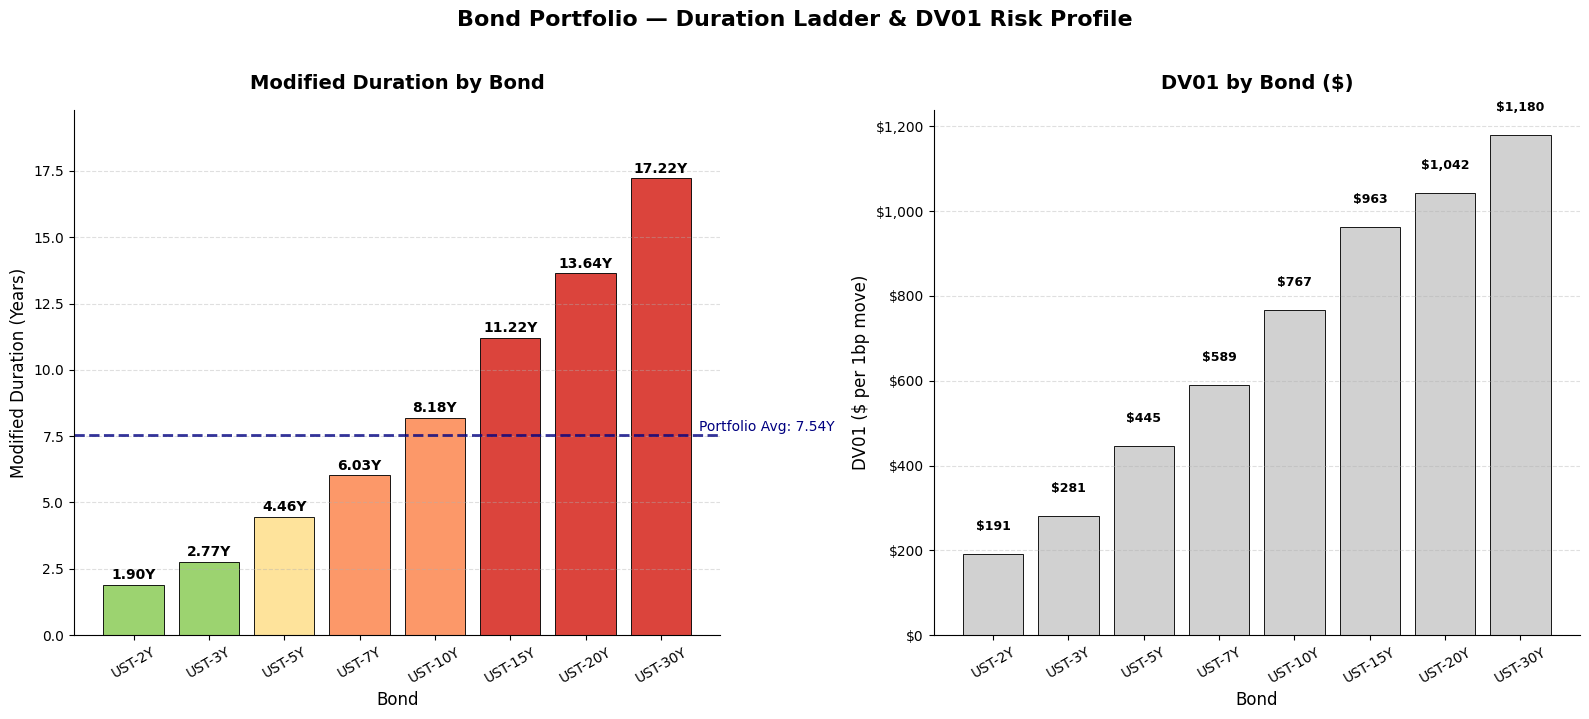

✅ Duration ladder chart saved.


In [ ]:
# ============================================================
# CELL 10: VISUALIZATION 2 — DURATION LADDER (BAR CHART)
# ============================================================

def plot_duration_ladder(risk_df):
    """
    Duration ladder shows the interest rate sensitivity
    distribution across the portfolio.
    A 'ladder' portfolio has evenly spread duration —
    like ladder rungs at each maturity. This is a key
    portfolio construction concept.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    bonds = risk_df['Bond ID']
    colors_dur = ['#d73027' if d > 10 else '#fc8d59' if d > 6
                  else '#fee090' if d > 4 else '#91cf60'
                  for d in risk_df['Mod Duration']]

    # --- Left: Modified Duration Bar ---
    bars1 = axes[0].bar(bonds, risk_df['Mod Duration'],
                        color=colors_dur, edgecolor='black', linewidth=0.7, alpha=0.9)
    axes[0].set_title('Modified Duration by Bond', fontsize=14, fontweight='bold', pad=15)
    axes[0].set_xlabel('Bond', fontsize=12)
    axes[0].set_ylabel('Modified Duration (Years)', fontsize=12)
    axes[0].set_ylim(0, risk_df['Mod Duration'].max() * 1.15)
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].grid(axis='y', alpha=0.4, linestyle='--')
    axes[0].spines[['top', 'right']].set_visible(False)

    # Add value labels on bars
    for bar, val in zip(bars1, risk_df['Mod Duration']):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     f'{val:.2f}Y', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Add portfolio average line
    port_dur = (risk_df['Mod Duration'] * risk_df['Market Value ($)']).sum() / \
                risk_df['Market Value ($)'].sum()
    axes[0].axhline(port_dur, color='navy', linestyle='--', linewidth=2, alpha=0.8)
    axes[0].text(len(bonds)-0.5, port_dur + 0.15,
                 f'Portfolio Avg: {port_dur:.2f}Y', color='navy', fontsize=10)

    # --- Right: DV01 Bar ---
    colors_dv01 = ['#4d4d4d' if dv > 8000 else '#969696'
                   if dv > 3000 else '#cccccc' for dv in risk_df['DV01 ($)']]
    bars2 = axes[1].bar(bonds, risk_df['DV01 ($)'],
                        color=colors_dv01, edgecolor='black', linewidth=0.7, alpha=0.9)
    axes[1].set_title('DV01 by Bond ($)', fontsize=14, fontweight='bold', pad=15)
    axes[1].set_xlabel('Bond', fontsize=12)
    axes[1].set_ylabel('DV01 ($ per 1bp move)', fontsize=12)
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].grid(axis='y', alpha=0.4, linestyle='--')
    axes[1].spines[['top', 'right']].set_visible(False)
    axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(
        lambda x, _: f'${x:,.0f}'))

    for bar, val in zip(bars2, risk_df['DV01 ($)']):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                     f'${val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.suptitle('Bond Portfolio — Duration Ladder & DV01 Risk Profile',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{base_path}/outputs/charts/duration_ladder.png',
                dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print("✅ Duration ladder chart saved.")


plot_duration_ladder(risk_df)


In [ ]:
# ============================================================
# CELL 11: VISUALIZATION 3 — P&L SCENARIO HEATMAP
# ============================================================

# Execute scenario analysis to get scenario_df and summary_df
scenario_df, summary_df = run_scenario_analysis(portfolio, spot_dict, risk_df)

def plot_scenario_heatmap(scenario_df):
    """
    A heatmap is perfect for scenario analysis:
    - Rows = individual bonds
    - Columns = rate scenarios
    - Colour = P&L magnitude (red = loss, green = gain)

    This is literally the morning risk report format used
    by traders at Barclays and Goldman.
    """
    # Transpose so bonds are rows, scenarios are columns
    heatmap_data = scenario_df.T  # shape: (scenarios, bonds)

    # Create diverging colour scale centered at 0
    max_abs = max(abs(heatmap_data.values.min()), abs(heatmap_data.values.max()))

    fig = go.Figure(data=go.Heatmap(
        z=heatmap_data.values,
        x=heatmap_data.columns.tolist(),
        y=heatmap_data.index.tolist(),
        colorscale=[
            [0.0, '#d73027'],     # Deep red (large losses)
            [0.25, '#f46d43'],
            [0.45, '#fdae61'],
            [0.5, '#ffffbf'],     # Yellow (near zero)
            [0.55, '#a6d96a'],
            [0.75, '#66bd63'],
            [1.0, '#1a9641']      # Deep green (large gains)
        ],
        zmid=0,
        zmin=-max_abs,
        zmax=max_abs,
        text=[[f'${v:,.0f}' for v in row] for row in heatmap_data.values],
        texttemplate='%{text}',
        textfont=dict(size=11, color='black'),
        showscale=True,
        colorbar=dict(
            title=dict(text='P&L ($)', font=dict(size=12)),
            tickformat='$,.0f',
            len=0.85
        )
    ))

    fig.update_layout(
        title=dict(
            text='Portfolio P&L Scenario Heatmap<br>'
                 '<sup>Green = Gain | Red = Loss | Each cell = $ P&L per scenario/bond</sup>',
            font=dict(size=16, family='Arial Black')
        ),
        xaxis=dict(title='Bond', tickangle=-30, tickfont=dict(size=11)),
        yaxis=dict(title='Rate Scenario', tickfont=dict(size=11)),
        plot_bgcolor='white',
        paper_bgcolor='white',
        width=1100, height=620,
        margin=dict(l=180, r=80, t=100, b=80)
    )

    fig.write_html(f'{base_path}/outputs/charts/scenario_heatmap.html')
    fig.show()
    print("✅ Scenario heatmap saved.")


plot_scenario_heatmap(scenario_df)


📉 Scenario Analysis Results (P&L in $):
 📈      Parallel -100bp: $    +587,287.87
 📈       Parallel -50bp: $    +283,248.86
 📈       Parallel -25bp: $    +139,151.09
 📉       Parallel +25bp: $    -134,437.53
 📉       Parallel +50bp: $    -264,381.46
 📉      Parallel +100bp: $    -511,607.74
 📉       Bull Steepener: $     -64,370.75
 📉       Bear Flattener: $        -788.73
 📉     Butterfly (Hump): $     -96,719.98


✅ Scenario heatmap saved.


In [ ]:
# ============================================================
# CELL 12: VISUALIZATION 4 — HISTORICAL ANIMATED YIELD CURVE
# ============================================================

def plot_historical_animated_curve(yields_df_clean, sample_freq='QS'):
    """
    Creates an animated Plotly chart showing how the yield
    curve has evolved from 2000 to present.

    We sample quarterly to keep the animation smooth and fast.

    This is the "wow factor" chart for your GitHub portfolio —
    it makes the concept of inversion, steepening, and flattening
    instantly visual.
    """
    # Use subset of maturities with most complete data
    key_mats = [0.25, 0.5, 1.0, 2.0, 5.0, 7.0, 10.0, 30.0]
    available = [m for m in key_mats if m in yields_df_clean.columns]
    df_sub = yields_df_clean[available].dropna()

    # Resample to quarterly
    df_q = df_sub.resample(sample_freq).last().dropna()

    frames = []
    for date, row in df_q.iterrows():
        frames.append(go.Frame(
            data=[go.Scatter(
                x=available,
                y=row.values * 100,
                mode='lines+markers',
                line=dict(color='#1f77b4', width=3),
                marker=dict(size=8),
                name=str(date.date())
            )],
            name=str(date.date()),
            layout=go.Layout(
                title_text=f'US Treasury Yield Curve — {date.strftime("%b %Y")}'
            )
        ))

    # Initial frame
    first_date = df_q.index[0]
    fig = go.Figure(
        data=[go.Scatter(
            x=available,
            y=df_q.iloc[0].values * 100,
            mode='lines+markers',
            line=dict(color='#1f77b4', width=3),
            marker=dict(size=8)
        )],
        layout=go.Layout(
            title=f'US Treasury Yield Curve — {first_date.strftime("%b %Y")}',
            xaxis=dict(
                title='Maturity (Years)',
                range=[0, 32],
                tickvals=available,
                ticktext=[f'{m:.2f}Y' if m < 1 else f'{int(m)}Y' for m in available]
            ),
            yaxis=dict(
                title='Yield (%)', range=[-0.5, 10],
                ticksuffix='%'
            ),
            plot_bgcolor='white',
            paper_bgcolor='white',
            width=950, height=550,
            updatemenus=[dict(
                type='buttons',
                showactive=False,
                y=1.15,
                buttons=[
                    dict(label='▶ Play',
                         method='animate',
                         args=[None, dict(frame=dict(duration=120, redraw=True),
                                          fromcurrent=True)]),
                    dict(label='⏸ Pause',
                         method='animate',
                         args=[[None], dict(frame=dict(duration=0, redraw=False),
                                            mode='immediate')])
                ]
            )],
            sliders=[dict(
                currentvalue=dict(prefix='Date: ', font=dict(size=12)),
                steps=[dict(args=[[f.name],
                                  dict(frame=dict(duration=0, redraw=True),
                                       mode='immediate')],
                            label=f.name,
                            method='animate')
                       for f in frames]
            )]
        ),
        frames=frames
    )

    fig.write_html(f'{base_path}/outputs/charts/historical_animation.html')
    fig.show()
    print("✅ Historical animation saved.")


plot_historical_animated_curve(yields_clean)


✅ Historical animation saved.


✅ NSS Calibration Complete:
  β0 (level):        0.055472
  β1 (slope):        -0.018245
  β2 (curvature 1):  0.006239
  β3 (curvature 2):  -0.027241
  τ1 (decay 1):      2.000000
  τ2 (decay 2):      5.000000


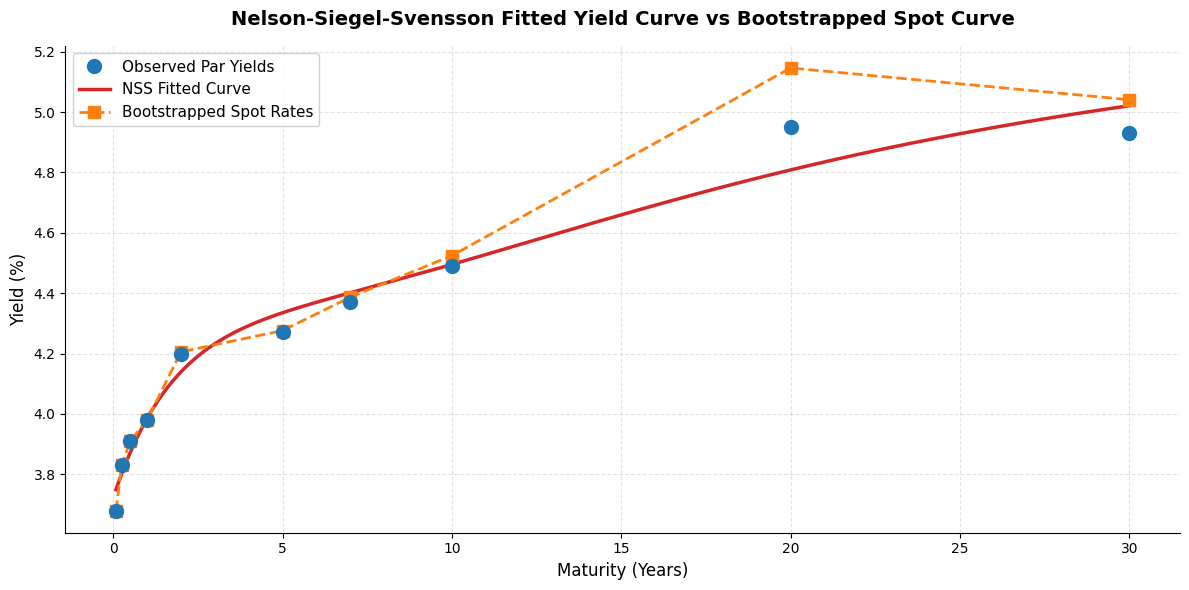

✅ NSS chart saved.


In [ ]:
# ============================================================
# CELL 13: NELSON-SIEGEL-SVENSSON CURVE FITTING (ENHANCEMENT)
# ============================================================
#
# WHAT IS NSS (ELI5):
# Instead of connecting dots (interpolation), NSS fits a
# smooth mathematical formula to the yield curve. The formula
# has 6 parameters (β0, β1, β2, β3, τ1, τ2) that control:
#   β0 = long-term level (where curve converges at infinity)
#   β1 = slope (how steep it is)
#   β2 = medium-term hump/trough
#   β3 = second hump (flexibility)
#
# The ECB and Bank of England use NSS officially.
# ============================================================

try:
    from nelson_siegel_svensson import NelsonSiegelSvenssonCurve
    from nelson_siegel_svensson.calibrate import calibrate_nss_ols

    t_obs = maturities
    y_obs = par_yields  # Fit to par yields

    # Calibrate NSS to observed yields (OLS minimization)
    curve_nss, status = calibrate_nss_ols(t_obs, y_obs)

    print("✅ NSS Calibration Complete:")
    print(f"  β0 (level):        {curve_nss.beta0:.6f}")
    print(f"  β1 (slope):        {curve_nss.beta1:.6f}")
    print(f"  β2 (curvature 1):  {curve_nss.beta2:.6f}")
    print(f"  β3 (curvature 2):  {curve_nss.beta3:.6f}")
    print(f"  τ1 (decay 1):      {curve_nss.tau1:.6f}")
    print(f"  τ2 (decay 2):      {curve_nss.tau2:.6f}")

    # Generate smooth curve for plotting
    t_smooth = np.linspace(0.08, 30, 300)
    nss_yields = curve_nss(t_smooth)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(maturities, par_yields * 100, 'o', markersize=10,
            color='#1f77b4', zorder=5, label='Observed Par Yields', linewidth=2)
    ax.plot(t_smooth, nss_yields * 100, '-',
            color='#d62728', linewidth=2.5, label='NSS Fitted Curve')
    ax.plot(maturities, spot_rates * 100, 's--',
            color='#ff7f0e', markersize=8, linewidth=2, label='Bootstrapped Spot Rates')

    ax.set_title('Nelson-Siegel-Svensson Fitted Yield Curve vs Bootstrapped Spot Curve',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Maturity (Years)', fontsize=12)
    ax.set_ylabel('Yield (%)', fontsize=12)
    ax.legend(fontsize=11, framealpha=0.9)
    ax.grid(True, alpha=0.35, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'{base_path}/outputs/charts/nss_fit.png',
                dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print("✅ NSS chart saved.")

except ImportError:
    print("⚠️ nelson-siegel-svensson not installed. Run: !pip install nelson-siegel-svensson")
except Exception as e:
    print(f"⚠️ NSS fitting failed: {e}")


In [ ]:
# ============================================================
# CELL 14: EXCEL EXPORT — PROFESSIONAL RISK REPORT
# ============================================================
#
# This creates a formatted Excel workbook that looks like
# a real bank risk report. Three sheets:
# 1. Yield Curve Data (par, spot, forward rates)
# 2. Bond Risk Metrics (duration, DV01, convexity)
# 3. Scenario P&L Heatmap (colour-coded)
# ============================================================

def export_excel_risk_report(spot_df, fwd_df, risk_df, scenario_df, summary_df,
                              output_path):
    """
    Exports a professionally formatted Excel risk report.
    Uses openpyxl for fine-grained formatting control.
    """
    from openpyxl import Workbook
    from openpyxl.styles import (PatternFill, Font, Alignment, Border,
                                  Side, numbers)
    from openpyxl.utils import get_column_letter
    from openpyxl.formatting.rule import ColorScaleRule

    wb = Workbook()

    # ---- Colour Palette ----
    DARK_BLUE = "1F3864"
    MID_BLUE  = "2E75B6"
    LIGHT_BLUE= "D6E4F0"
    GREEN     = "1A9641"
    RED       = "D73027"
    YELLOW    = "FFF2CC"
    WHITE     = "FFFFFF"
    GRAY      = "F2F2F2"

    def style_header_row(ws, row_num, num_cols,
                         bg_color=DARK_BLUE, font_color=WHITE):
        """Applies dark header style to a full row."""
        for col in range(1, num_cols + 1):
            cell = ws.cell(row=row_num, column=col)
            cell.fill = PatternFill("solid", fgColor=bg_color)
            cell.font = Font(bold=True, color=font_color, size=11)
            cell.alignment = Alignment(horizontal='center', vertical='center')
            cell.border = Border(
                bottom=Side(style='medium', color='000000'),
                top=Side(style='thin', color='000000'),
                left=Side(style='thin', color='BBBBBB'),
                right=Side(style='thin', color='BBBBBB')
            )

    def auto_size_columns(ws, min_width=10, max_width=30):
        """Auto-adjusts column widths based on content."""
        for column in ws.columns:
            max_len = 0
            col_letter = get_column_letter(column[0].column)
            for cell in column:
                try:
                    if cell.value:
                        max_len = max(max_len, len(str(cell.value)))
                except:
                    pass
            ws.column_dimensions[col_letter].width = max(
                min_width, min(max_width, max_len + 2))

    # ============================================================
    # SHEET 1: Yield Curve Data
    # ============================================================
    ws1 = wb.active
    ws1.title = "Yield Curve"

    # Title
    ws1.merge_cells('A1:D1')
    ws1['A1'] = f"US Treasury Yield Curve Analysis — {datetime.now().strftime('%d %b %Y')}"
    ws1['A1'].font = Font(bold=True, size=14, color=DARK_BLUE)
    ws1['A1'].alignment = Alignment(horizontal='center')
    ws1.row_dimensions[1].height = 30

    headers = ['Maturity (Y)', 'Par Yield (%)', 'Spot Rate (%)', 'Forward Rate (%)']
    for j, h in enumerate(headers, 1):
        ws1.cell(row=2, column=j, value=h)
    style_header_row(ws1, 2, len(headers))

    for i, row in fwd_df.iterrows():
        r = i + 3
        ws1.cell(r, 1, round(float(row['maturity']), 4))
        ws1.cell(r, 2, round(float(row['par_yield']) * 100, 4))
        ws1.cell(r, 3, round(float(row['spot_rate']) * 100, 4))
        ws1.cell(r, 4, round(float(row['forward_rate']) * 100, 4))
        # Alternate row shading
        fill = PatternFill("solid", fgColor=GRAY if i % 2 == 0 else WHITE)
        for col in range(1, 5):
            ws1.cell(r, col).fill = fill
            ws1.cell(r, col).alignment = Alignment(horizontal='center')

    # Add a simple chart in Excel
    from openpyxl.chart import LineChart, Reference
    chart1 = LineChart()
    chart1.title = "Yield Curves"
    chart1.style = 10
    chart1.y_axis.title = "Yield (%)"
    chart1.x_axis.title = "Maturity"
    chart1.height = 14
    chart1.width = 24

    par_ref = Reference(ws1, min_col=2, min_row=2, max_row=2+len(fwd_df))
    spot_ref = Reference(ws1, min_col=3, min_row=2, max_row=2+len(fwd_df))
    fwd_ref  = Reference(ws1, min_col=4, min_row=2, max_row=2+len(fwd_df))
    chart1.add_data(par_ref, titles_from_data=True)
    chart1.add_data(spot_ref, titles_from_data=True)
    chart1.add_data(fwd_ref, titles_from_data=True)
    ws1.add_chart(chart1, "F2")

    auto_size_columns(ws1)

    # ============================================================
    # SHEET 2: Bond Risk Metrics
    # ============================================================
    ws2 = wb.create_sheet("Bond Risk Metrics")

    ws2.merge_cells('A1:K1')
    ws2['A1'] = "Bond Portfolio — Risk Metrics Report"
    ws2['A1'].font = Font(bold=True, size=14, color=DARK_BLUE)
    ws2['A1'].alignment = Alignment(horizontal='center')
    ws2.row_dimensions[1].height = 28

    headers2 = list(risk_df.columns)
    for j, h in enumerate(headers2, 1):
        ws2.cell(2, j, h)
    style_header_row(ws2, 2, len(headers2))

    for i, row in risk_df.iterrows():
        r = i + 3
        for j, val in enumerate(row, 1):
            cell = ws2.cell(r, j)
            if isinstance(val, float):
                cell.value = round(val, 4)
                if 'Value' in headers2[j-1] or 'DV01' in headers2[j-1] or 'Duration ($)' in headers2[j-1]:
                    cell.number_format = '#,##0.00'
                else:
                    cell.number_format = '0.0000'
            else:
                cell.value = val
            fill_color = GRAY if i % 2 == 0 else WHITE
            cell.fill = PatternFill("solid", fgColor=fill_color)
            cell.alignment = Alignment(horizontal='center')

    # Totals row
    total_row = len(risk_df) + 4
    ws2.cell(total_row, 1, "PORTFOLIO TOTAL").font = Font(bold=True, color=WHITE)
    ws2.cell(total_row, 1).fill = PatternFill("solid", fgColor=DARK_BLUE)
    ws2.cell(total_row, 6, risk_df['Market Value ($)'].sum()).number_format = '#,##0.00'
    ws2.cell(total_row, 10, risk_df['DV01 ($)'].sum()).number_format = '#,##0.00'
    for col in range(1, len(headers2)+1):
        ws2.cell(total_row, col).fill = PatternFill("solid", fgColor=DARK_BLUE)
        ws2.cell(total_row, col).font = Font(bold=True, color=WHITE)

    auto_size_columns(ws2)

    # ============================================================
    # SHEET 3: Scenario Analysis P&L
    # ============================================================
    ws3 = wb.create_sheet("Scenario Analysis")

    ws3.merge_cells('A1:J1')
    ws3['A1'] = "Scenario P&L Analysis — Rate Shock Impact"
    ws3['A1'].font = Font(bold=True, size=14, color=DARK_BLUE)
    ws3['A1'].alignment = Alignment(horizontal='center')
    ws3.row_dimensions[1].height = 28

    # Headers: bond IDs across columns
    ws3.cell(2, 1, 'Scenario')
    bond_ids = scenario_df.columns.tolist()
    for j, bid in enumerate(bond_ids, 2):
        ws3.cell(2, j, bid)
    ws3.cell(2, len(bond_ids)+2, 'TOTAL P&L ($)')
    style_header_row(ws3, 2, len(bond_ids)+2)

    # Data rows
    total_pnl_col = len(bond_ids) + 2
    for i, scenario in enumerate(scenario_df.index):
        r = i + 3
        ws3.cell(r, 1, scenario)
        row_total = 0
        for j, bond_id in enumerate(bond_ids, 2):
            val = scenario_df.loc[scenario, bond_id]
            cell = ws3.cell(r, j, round(val, 2))
            cell.number_format = '#,##0.00'
            cell.alignment = Alignment(horizontal='right')
            row_total += val

        total_cell = ws3.cell(r, total_pnl_col, round(row_total, 2))
        total_cell.number_format = '#,##0.00'
        total_cell.font = Font(bold=True)
        # Color total: green if positive, red if negative
        if row_total >= 0:
            total_cell.fill = PatternFill("solid", fgColor="C6EFCE")
            total_cell.font = Font(bold=True, color="276221")
        else:
            total_cell.fill = PatternFill("solid", fgColor="FFC7CE")
            total_cell.font = Font(bold=True, color="9C0006")

    # Apply conditional formatting (colour scale) to P&L cells
    from openpyxl.formatting.rule import ColorScaleRule
    pnl_range = f"B3:{get_column_letter(len(bond_ids)+1)}{2+len(scenario_df)}"
    ws3.conditional_formatting.add(
        pnl_range,
        ColorScaleRule(
            start_type='min', start_color='F8696B',   # Red for losses
            mid_type='num',   mid_value=0,   mid_color='FFEB84',  # Yellow at zero
            end_type='max',   end_color='63BE7B'        # Green for gains
        )
    )

    auto_size_columns(ws3)

    # Save workbook
    wb.save(output_path)
    print(f"✅ Excel risk report saved: {output_path}")
    print(f"   Sheets: Yield Curve | Bond Risk Metrics | Scenario Analysis")


export_excel_risk_report(
    spot_df, fwd_df, risk_df, scenario_df, summary_df,
    output_path=f'{base_path}/outputs/reports/risk_report.xlsx'
)


✅ Excel risk report saved: /content/drive/MyDrive/FixedIncome_YieldCurve/outputs/reports/risk_report.xlsx
   Sheets: Yield Curve | Bond Risk Metrics | Scenario Analysis


In [ ]:
# ============================================================
# CELL 15: PERFORMANCE METRICS & VALIDATION
# ============================================================

def validate_and_report(maturities, par_yields, spot_rates,
                        forward_rates, risk_df, scenario_df):
    """
    Validates model outputs and prints a professional summary.
    These are the sanity checks a real quant would run.
    """
    print("=" * 65)
    print("   YIELD CURVE CONSTRUCTION — VALIDATION REPORT")
    print("=" * 65)

    # 1. No-Arbitrage Check: Spot rates should reprice par bonds at ~100
    print("\n✅ No-Arbitrage Validation (par bonds should price at $100):")
    for T, par, spot in zip(maturities, par_yields, spot_rates):
        price = bond_price_from_spots(par, T, dict(zip(maturities, spot_rates)))
        error = abs(price - 100)
        flag = "✅" if error < 0.01 else "⚠️"
        print(f"  {flag} {T:.2f}Y: Repriced = {price:.4f} | Error = {error:.6f}")

    # 2. Forward Rate Consistency Check
    print("\n✅ Forward Rate Consistency:")
    for i in range(1, len(maturities)):
        t1, t2 = maturities[i-1], maturities[i]
        s1, s2 = spot_rates[i-1], spot_rates[i]
        f = forward_rates[i]
        # Verify: (1+s2)^t2 = (1+s1)^t1 * (1+f)^(t2-t1)
        lhs = (1+s2)**t2
        rhs = (1+s1)**t1 * (1+f)**(t2-t1)
        error = abs(lhs-rhs)
        flag = "✅" if error < 1e-8 else "⚠️"
        print(f"  {flag} f({t1:.2f}→{t2:.2f}): {f*100:.4f}% | Check error: {error:.2e}")

    # 3. Duration Reasonableness
    print("\n✅ Duration Sanity (ModDur should be < Maturity):")
    for _, row in risk_df.iterrows():
        flag = "✅" if row['Mod Duration'] < row['Maturity (Y)'] else "⚠️"
        print(f"  {flag} {row['Bond ID']:>10}: ModDur = {row['Mod Duration']:.3f}Y "
              f"| Maturity = {row['Maturity (Y)']:.1f}Y")

    # 4. Portfolio Summary
    total_mv = risk_df['Market Value ($)'].sum()
    total_dv01 = risk_df['DV01 ($)'].sum()
    wtd_dur = (risk_df['Mod Duration'] * risk_df['Market Value ($)']).sum() / total_mv
    wtd_conv = (risk_df['Convexity'] * risk_df['Market Value ($)']).sum() / total_mv
    pnl_100 = summary_df.loc[summary_df['Scenario']=='Parallel +100bp', 'Total P&L ($)'].values[0]

    print(f"\n📊 PORTFOLIO RISK SUMMARY:")
    print(f"  {'Total Market Value':.<40} ${total_mv:>15,.2f}")
    print(f"  {'Total DV01':.<40} ${total_dv01:>15,.2f}")
    print(f"  {'Weighted Average Duration':.<40} {wtd_dur:>15.4f} years")
    print(f"  {'Weighted Average Convexity':.<40} {wtd_conv:>15.4f}")
    print(f"  {'P&L on +100bp Parallel Shock':.<40} ${pnl_100:>+15,.2f}")
    print(f"  {'Duration × DV01 Consistency':.<40} {abs(pnl_100 / (total_dv01 * 100)):>15.4f}x")
    print("\n" + "=" * 65)


validate_and_report(maturities, par_yields, spot_rates,
                    forward_rates, risk_df, scenario_df)


   YIELD CURVE CONSTRUCTION — VALIDATION REPORT

✅ No-Arbitrage Validation (par bonds should price at $100):
  ⚠️ 0.08Y: Repriced = 99.6944 | Error = 0.305607
  ⚠️ 0.25Y: Repriced = 99.0516 | Error = 0.948419
  ✅ 0.50Y: Repriced = 100.0000 | Error = 0.000000
  ✅ 1.00Y: Repriced = 100.0007 | Error = 0.000670
  ✅ 2.00Y: Repriced = 100.0000 | Error = 0.000000
  ✅ 5.00Y: Repriced = 100.0000 | Error = 0.000000
  ✅ 7.00Y: Repriced = 100.0000 | Error = 0.000000
  ✅ 10.00Y: Repriced = 100.0000 | Error = 0.000000
  ✅ 20.00Y: Repriced = 100.0000 | Error = 0.000000
  ✅ 30.00Y: Repriced = 100.0000 | Error = 0.000000

✅ Forward Rate Consistency:
  ✅ f(0.08→0.25): 3.9050% | Check error: 0.00e+00
  ✅ f(0.25→0.50): 3.9901% | Check error: 0.00e+00
  ✅ f(0.50→1.00): 4.0500% | Check error: 0.00e+00
  ✅ f(1.00→2.00): 4.4318% | Check error: 0.00e+00
  ✅ f(2.00→5.00): 4.3234% | Check error: 2.22e-16
  ✅ f(5.00→7.00): 4.6639% | Check error: 0.00e+00
  ✅ f(7.00→10.00): 4.8463% | Check error: 2.22e-16
  ✅ f(10

  PCA input: 6617 daily observations × 9 maturities
  Date range: 2000-01-04 → 2026-06-17
  Maturities: ['0.25Y', '0.50Y', '1Y', '2Y', '5Y', '7Y', '10Y', '20Y', '30Y']

╔══════════════════════════════════════════════════════╗
║          PCA — Explained Variance                   ║
╠══════════════════════════════════════════════════════╣
║  PC1: 75.29%  █████████████████████████████████████              ║
║  PC2: 14.35%  ███████                                            ║
║  PC3:  5.78%  ██                                                 ║
║  Total (3 PCs): 95.430% of all yield curve variance ║
╚══════════════════════════════════════════════════════╝

  Component Interpretation:
  PC    Name         1σ Shock (bp)    Loadings (short→long)
  ----------------------------------------------------------------------
  PC1   Level           13.66 bp       +0.108  +0.145  +0.217  +0.346  +0.432  +0.438  +0.412  +0.370  +0.340
  PC2   Slope            5.96 bp       +0.582  +0.470  +0.409  +0.267

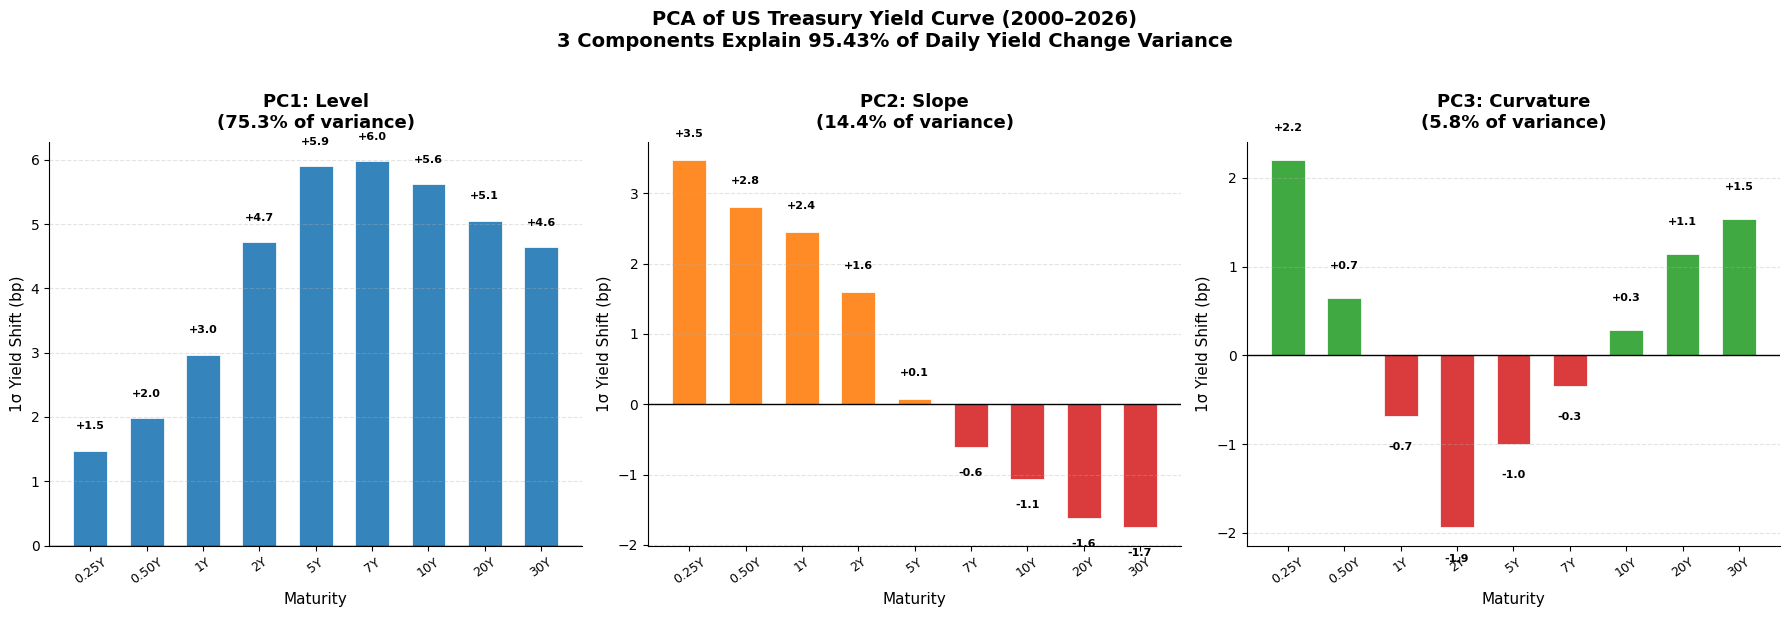

✓ PCA loadings chart saved.


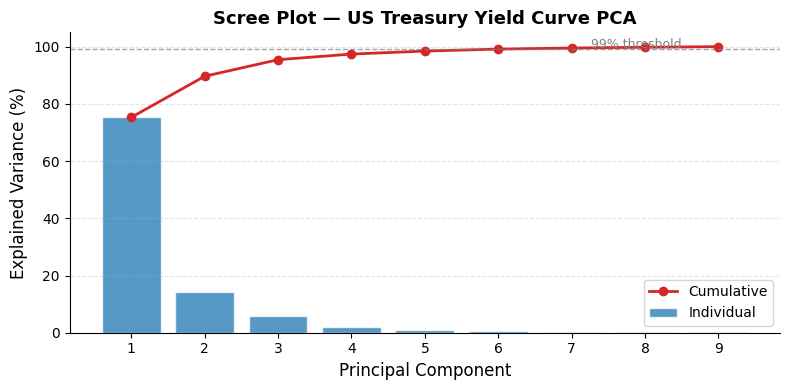

✓ Scree plot saved.


In [135]:
# ============================================================
# CELL 15: PRINCIPAL COMPONENT ANALYSIS (PCA) OF YIELD CURVE
# ============================================================
# WHAT IS THIS (ELI5):
# The yield curve has 10 points (0.08Y → 30Y), but when rates
# move, they don't move randomly — they move together in
# predictable patterns. PCA finds those patterns.
#
# Empirically, 3 components explain ~99% of all yield curve moves:
#   PC1 = "Level"     → all maturities move up/down together (~85%)
#   PC2 = "Slope"     → short end and long end move opposite (~10%)
#   PC3 = "Curvature" → belly moves opposite to short+long ends (~3%)
#
# WHY TRADERS CARE:
# - If you're long PC1 (level), a parallel shift kills you
# - If you're long PC2 (slope), you're betting on steepening/flattening
# - If you're long PC3 (curvature), you're running a butterfly trade
#
# This is literally how rates desks at Goldman / Barclays think
# about hedging. "What's my PC1 exposure?" = "What's my DV01?"
# ============================================================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# ── 1. DATA PREPARATION ──────────────────────────────────────
# Use daily yield CHANGES (not levels) — PCA on changes gives
# us the covariance structure of how rates co-move each day.
# Drop maturities with >5% missing to keep the panel balanced.

yields_for_pca = yields_clean.copy()
# Keep only columns with less than 5% missing
yields_for_pca = yields_for_pca.loc[:, yields_for_pca.isnull().mean() < 0.05]
# Drop any remaining rows with NaN across the kept columns
yields_for_pca = yields_for_pca.dropna()
# Compute daily yield changes (in basis points for interpretability)
yield_changes = yields_for_pca.diff().dropna() * 10_000  # bps

pca_maturities = np.array(yields_for_pca.columns, dtype=float)
maturity_labels = [f'{m:.2f}Y' if m < 1 else f'{m:.0f}Y' for m in pca_maturities]

print(f"  PCA input: {yield_changes.shape[0]} daily observations × "
      f"{yield_changes.shape[1]} maturities")
print(f"  Date range: {yield_changes.index[0].date()} → {yield_changes.index[-1].date()}")
print(f"  Maturities: {maturity_labels}")

# ── 2. FIT PCA ────────────────────────────────────────────────
# We do NOT standardise here — we want to preserve the natural
# variance differences across maturities (short end is more
# volatile). StandardScaler would destroy that information.
n_components = 3
pca = PCA(n_components=n_components)
pca.fit(yield_changes.values)

explained   = pca.explained_variance_ratio_
cumulative  = np.cumsum(explained)
pc_stds     = np.sqrt(pca.explained_variance_)   # 1-sigma shock in bps
loadings    = pca.components_                     # shape: (3, n_maturities)

print("\n╔══════════════════════════════════════════════════════╗")
print("║          PCA — Explained Variance                   ║")
print("╠══════════════════════════════════════════════════════╣")
for i in range(n_components):
    bar = '█' * int(explained[i] * 50)
    print(f"║  PC{i+1}: {explained[i]*100:5.2f}%  {bar:<50} ║")
print(f"║  Total (3 PCs): {cumulative[-1]*100:.3f}% of all yield curve variance ║")
print("╚══════════════════════════════════════════════════════╝")

# ── 3. INTERPRET THE COMPONENTS ───────────────────────────────
# Name each PC based on the sign pattern of its loadings:
#   Level     → all loadings same sign
#   Slope     → loadings flip sign from short to long end
#   Curvature → loadings negative at short+long, positive in belly
names = []
for i, loading in enumerate(loadings):
    if np.all(loading > 0) or np.all(loading < 0):
        names.append("Level")
    elif loading[0] * loading[-1] < 0:
        names.append("Slope")
    else:
        names.append("Curvature")

print("\n  Component Interpretation:")
print(f"  {'PC':<5} {'Name':<12} {'1σ Shock (bp)':<16} {'Loadings (short→long)'}")
print("  " + "-" * 70)
for i in range(n_components):
    load_str = "  ".join(f"{l:+.3f}" for l in loadings[i])
    print(f"  PC{i+1:<3} {names[i]:<12} {pc_stds[i]:>8.2f} bp       {load_str}")

# ── 4. BUILD PCA SHOCK VECTORS (for scenario engine) ─────────
# These are the rate shifts at each maturity for a 1-sigma move
# in each PC.  Sign convention: PC1 positive = rates up (normal).
# Flip PC1 if all loadings are negative (ensures "up" = positive).

pc1_shock = loadings[0].copy()
if np.mean(pc1_shock) < 0:          # ensure level shock is upward
    pc1_shock = -pc1_shock

pc2_shock = loadings[1].copy()      # slope: sign convention varies
pc3_shock = loadings[2].copy()      # curvature

def get_pca_shock_at_maturity(maturity, shock_vector, pc_maturity_arr):
    """Interpolate a PCA shock vector to any maturity (in bps)."""
    return float(np.interp(maturity, pc_maturity_arr, shock_vector))

print("\n  1-sigma PCA Shock at Key Maturities (bp):")
print(f"  {'Maturity':<12} {'PC1 Level':>12} {'PC2 Slope':>12} {'PC3 Curvature':>14}")
print("  " + "-" * 54)
for mat in [0.25, 2.0, 5.0, 10.0, 30.0]:
    s1 = get_pca_shock_at_maturity(mat, pc1_shock * pc_stds[0], pca_maturities)
    s2 = get_pca_shock_at_maturity(mat, pc2_shock * pc_stds[1], pca_maturities)
    s3 = get_pca_shock_at_maturity(mat, pc3_shock * pc_stds[2], pca_maturities)
    label = f'{mat:.2f}Y' if mat < 1 else f'{mat:.0f}Y'
    print(f"  {label:<12} {s1:>+11.2f}  {s2:>+11.2f}  {s3:>+13.2f}")

# ── 5. PCA SCENARIO P&L ───────────────────────────────────────
# Compute P&L for +1σ and -1σ of each PC across the portfolio.

def pca_scenario_pnl(portfolio, pca_maturities, shock_bp_vector,
                     label, curve_nss, spot_dict):
    """
    Computes portfolio P&L for a given PCA shock vector (in bps).
    shock_bp_vector: array of yield shifts in bps, one per pca_maturity.
    """
    results = {}
    for _, bond in portfolio.iterrows():
        T   = bond['maturity_yr']
        y0  = get_ytm_from_curve(T, curve=curve_nss, spot_dict=spot_dict)
        P0  = compute_bond_price(bond['coupon_rate'], T, y0,
                                 bond['face_value'], bond['freq'])
        # Interpolate shock to this bond's maturity
        dy_bp = get_pca_shock_at_maturity(T, shock_bp_vector, pca_maturities)
        dy    = dy_bp / 10_000.0        # convert bps → decimal
        y1    = y0 + dy
        P1    = compute_bond_price(bond['coupon_rate'], T, y1,
                                   bond['face_value'], bond['freq'])
        results[bond['bond_id']] = P1 - P0
    total = sum(results.values())
    arrow = "↑" if total > 0 else "↓"
    print(f"  {arrow} {label:<30}: ${total:>+12,.2f}  "
          f"(per bond: {', '.join(f'{v:+,.0f}' for v in results.values())})")
    return results

print("\n  PCA Scenario P&L (1-sigma shocks):")
print("  " + "=" * 75)
for sign, sign_label in [(+1, "+1σ"), (-1, "-1σ")]:
    for pc_idx, pc_name in enumerate(names):
        shock = sign * pc_stds[pc_idx] * (
            pc1_shock if pc_idx == 0 else
            pc2_shock if pc_idx == 1 else
            pc3_shock
        )
        label = f"PC{pc_idx+1} {pc_name} {sign_label}"
        pca_scenario_pnl(portfolio, pca_maturities, shock,
                         label, curve_nss, spot_dict)

# ── 6. VISUALIZATION ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors   = ['#1f77b4', '#ff7f0e', '#2ca02c']
pc_names = [f'PC{i+1}: {names[i]}' for i in range(n_components)]
shocks   = [pc1_shock * pc_stds[0],
            pc2_shock * pc_stds[1],
            pc3_shock * pc_stds[2]]

for i, (ax, shock, name, color) in enumerate(zip(axes, shocks, pc_names, colors)):
    bars = ax.bar(maturity_labels, shock,
                  color=[color if s >= 0 else '#d62728' for s in shock],
                  edgecolor='white', linewidth=0.6, alpha=0.9, width=0.6)

    ax.axhline(0, color='black', linewidth=1.0, linestyle='-')
    ax.set_title(f'{name}\n({explained[i]*100:.1f}% of variance)',
                 fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Maturity', fontsize=11)
    ax.set_ylabel('1σ Yield Shift (bp)', fontsize=11)
    ax.tick_params(axis='x', rotation=35, labelsize=9)
    ax.grid(axis='y', alpha=0.35, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

    # Annotate bars
    for bar, val in zip(bars, shock):
        va = 'bottom' if val >= 0 else 'top'
        offset = 0.3 if val >= 0 else -0.3
        ax.text(bar.get_x() + bar.get_width()/2,
                val + offset, f'{val:+.1f}',
                ha='center', va=va, fontsize=8, fontweight='bold')

plt.suptitle(
    f'PCA of US Treasury Yield Curve (2000–2026)\n'
    f'3 Components Explain {cumulative[-1]*100:.2f}% of Daily Yield Change Variance',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(f'{base_path}/outputs/charts/pca_loadings.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ PCA loadings chart saved.")

# ── 7. SCREE PLOT ─────────────────────────────────────────────
# Shows how many PCs are needed to explain the full curve.
pca_full = PCA().fit(yield_changes.values)
fig2, ax2 = plt.subplots(figsize=(8, 4))
n_show = min(10, len(pca_full.explained_variance_ratio_))
cumvar = np.cumsum(pca_full.explained_variance_ratio_[:n_show]) * 100

ax2.bar(range(1, n_show+1), pca_full.explained_variance_ratio_[:n_show] * 100,
        color='#1f77b4', alpha=0.75, edgecolor='white', label='Individual')
ax2.plot(range(1, n_show+1), cumvar, 'o-',
         color='#d62728', linewidth=2, markersize=6, label='Cumulative')
ax2.axhline(99, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax2.text(n_show - 0.5, 99.5, '99% threshold', ha='right',
         color='gray', fontsize=9)

ax2.set_xlabel('Principal Component', fontsize=12)
ax2.set_ylabel('Explained Variance (%)', fontsize=12)
ax2.set_title('Scree Plot — US Treasury Yield Curve PCA', fontsize=13, fontweight='bold')
ax2.set_xticks(range(1, n_show+1))
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.35, linestyle='--')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{base_path}/outputs/charts/pca_scree.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Scree plot saved.")


In [136]:
# Standard deviations of PCs (scale of daily changes)
pc_std = np.sqrt(pca.explained_variance_)

# 1-sigma level shock
level_shock = +1.0 * pc_std[0] * pc1_loadings   # array for each maturity

# 1-sigma slope shock
slope_steepener = +1.0 * pc_std[1] * pc2_loadings

# 1-sigma curvature shock
curvature_hump = +1.0 * pc_std[2] * pc3_loadings